<a href="https://colab.research.google.com/github/yawarabbasmalik/Impact-of-COVID-19-Vaccination-Campaigns-on-Public-Health/blob/main/EDA_and_ML_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Data Analysis USing EDA & Predictive Analysis

In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
# Read the train.csv file
train_data = pd.read_csv('train.csv')

# Read the test.csv file
test_data = pd.read_csv('test.csv')

# Read the submission.csv file
submission_data = pd.read_csv('submission.csv')


C:\Users\HP\AppData\Local\Temp/ipykernel_14080/1523811354.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('train.csv')


In [ ]:
train_data.head()

,Id,County,Province_State,Country_Region,Population,Weight,Date,Target,TargetValue
0,1,NaN,NaN,Afghanistan,27657145,0.058359,2020-01-23,ConfirmedCases,0
1,2,NaN,NaN,Afghanistan,27657145,0.583587,2020-01-23,Fatalities,0
2,3,NaN,NaN,Afghanistan,27657145,0.058359,2020-01-24,ConfirmedCases,0
3,4,NaN,NaN,Afghanistan,27657145,0.583587,2020-01-24,Fatalities,0
4,5,NaN,NaN,Afghanistan,27657145,0.058359,2020-01-25,ConfirmedCases,0


In [ ]:
# Drop the 'County' and 'Province_State' columns
train_data.drop(['County', 'Province_State', 'Id'], axis=1, inplace=True)


In [ ]:
train_data.head()

,Country_Region,Population,Weight,Date,Target,TargetValue
0,Afghanistan,27657145,0.058359,2020-01-23,ConfirmedCases,0
1,Afghanistan,27657145,0.583587,2020-01-23,Fatalities,0
2,Afghanistan,27657145,0.058359,2020-01-24,ConfirmedCases,0
3,Afghanistan,27657145,0.583587,2020-01-24,Fatalities,0
4,Afghanistan,27657145,0.058359,2020-01-25,ConfirmedCases,0


In [ ]:
# Check for null or missing values in the "Country_Region" column
null_values = train_data['Country_Region'].isnull().sum()

print("Number of null values in 'Country_Region' column:", null_values)

Number of null values in 'Country_Region' column: 0


### Which country is driving the growth?

Hypothesis: Countries with high population densities and limited healthcare infrastructure may experience faster growth.

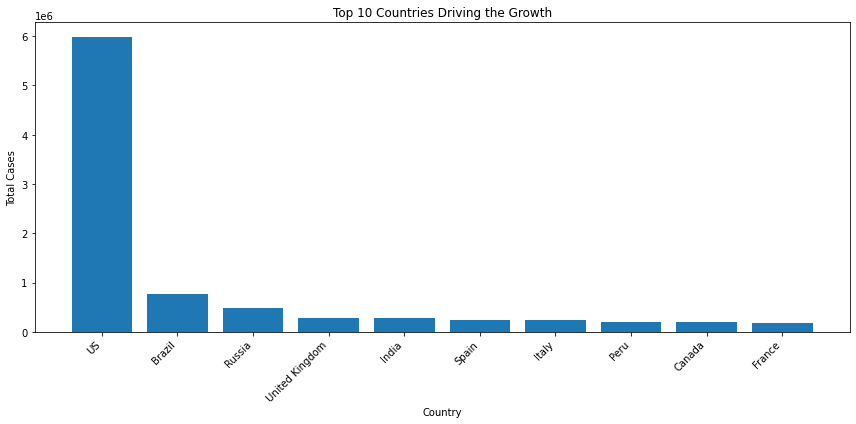

In [ ]:
# Group the data by country and calculate the total number of cases
country_cases = train_data[train_data['Target'] == 'ConfirmedCases'].groupby('Country_Region')['TargetValue'].sum()

# Sort the countries by the total number of cases in descending order
sorted_countries = country_cases.sort_values(ascending=False)

# Plot the top 10 countries driving the growth
top_10_countries = sorted_countries.head(10)
plt.figure(figsize=(12, 6))  # Adjust the figure size as per your requirement
plt.bar(top_10_countries.index, top_10_countries.values)
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.title('Top 10 Countries Driving the Growth')
plt.xticks(rotation=45, ha='right')  # Adjust the rotation and alignment of x-axis tick labels
plt.tight_layout()  # Adjust the spacing between the plot elements
plt.show()

### Which country is recovering?

Hypothesis: Countries with high vaccination rates and effective public health measures may show signs of recovery.

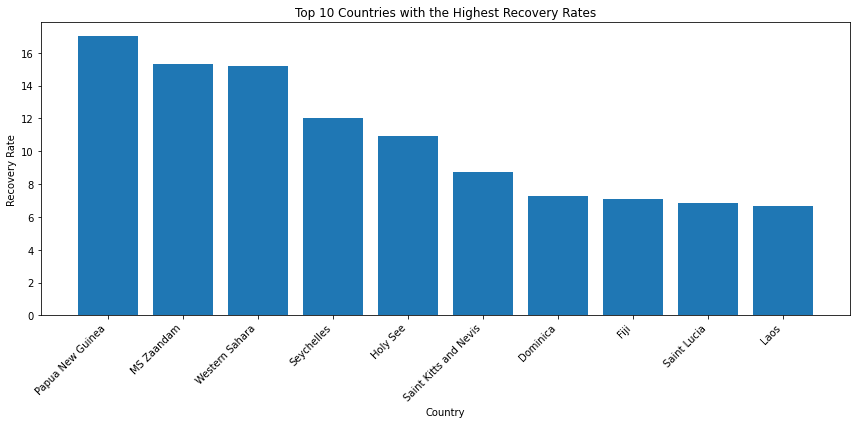

In [ ]:
# Group the data by country and calculate the total number of cases
country_cases = train_data[train_data['Target'] == 'ConfirmedCases'].groupby('Country_Region')['TargetValue'].sum()

# Group the data by country and calculate the total number of recovered cases
country_recovered_cases = train_data[(train_data['Target'] == 'ConfirmedCases') & (train_data['TargetValue'] == 0)].groupby('Country_Region')['TargetValue'].count()

# Calculate the recovery rate for each country
recovery_rate = country_recovered_cases / country_cases

# Sort the countries by the recovery rate in descending order
sorted_countries = recovery_rate.sort_values(ascending=False)

# Plot the top 10 countries with the highest recovery rates
top_10_countries = sorted_countries.head(10)
plt.figure(figsize=(12, 6))  # Adjust the figure size as per your requirement
plt.bar(top_10_countries.index, top_10_countries.values)
plt.xlabel('Country')
plt.ylabel('Recovery Rate')
plt.title('Top 10 Countries with the Highest Recovery Rates')
plt.xticks(rotation=45, ha='right')  # Adjust the rotation and alignment of x-axis tick labels
plt.tight_layout()  # Adjust the spacing between the plot elements
plt.show()

### How does the spreading pattern across the world look like?

Hypothesis: The spread of COVID-19 may initially concentrate in densely populated areas and later extend to other regions.

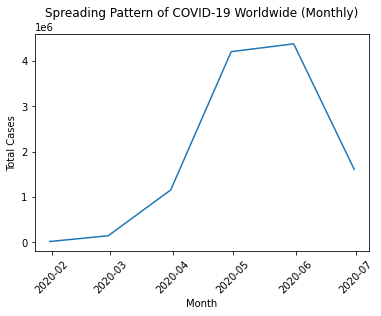

In [ ]:
# Convert the 'Date' column to datetime format
train_data['Date'] = pd.to_datetime(train_data['Date'])

# Group the data by month and calculate the total number of cases worldwide
total_cases_by_month = train_data[train_data['Target'] == 'ConfirmedCases'].groupby(pd.Grouper(key='Date', freq='M'))['TargetValue'].sum()

# Plot the spreading pattern across the world based on months
plt.plot(total_cases_by_month.index, total_cases_by_month.values)
plt.xlabel('Month')
plt.ylabel('Total Cases')
plt.title('Spreading Pattern of COVID-19 Worldwide (Monthly)')
plt.xticks(rotation=45)
plt.show()

### Cases and death trend?

Hypothesis: The number of cases and deaths may follow different trends based on factors such as testing capacity, healthcare infrastructure, and containment measures.

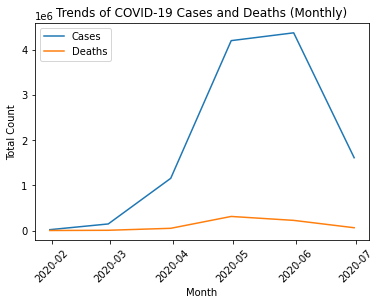

In [ ]:
# Convert the 'Date' column to datetime format
train_data['Date'] = pd.to_datetime(train_data['Date'])

# Group the data by month and calculate the total number of cases and deaths worldwide
total_cases_by_month = train_data[train_data['Target'] == 'ConfirmedCases'].groupby(pd.Grouper(key='Date', freq='M'))['TargetValue'].sum()
total_deaths_by_month = train_data[train_data['Target'] == 'Fatalities'].groupby(pd.Grouper(key='Date', freq='M'))['TargetValue'].sum()

# Plot the trends of cases and deaths over time
plt.plot(total_cases_by_month.index, total_cases_by_month.values, label='Cases')
plt.plot(total_deaths_by_month.index, total_deaths_by_month.values, label='Deaths')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.title('Trends of COVID-19 Cases and Deaths (Monthly)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### How does the testing rate affect the number of confirmed cases?

Hypothesis: Countries with higher testing rates may report a higher number of confirmed cases due to increased detection.

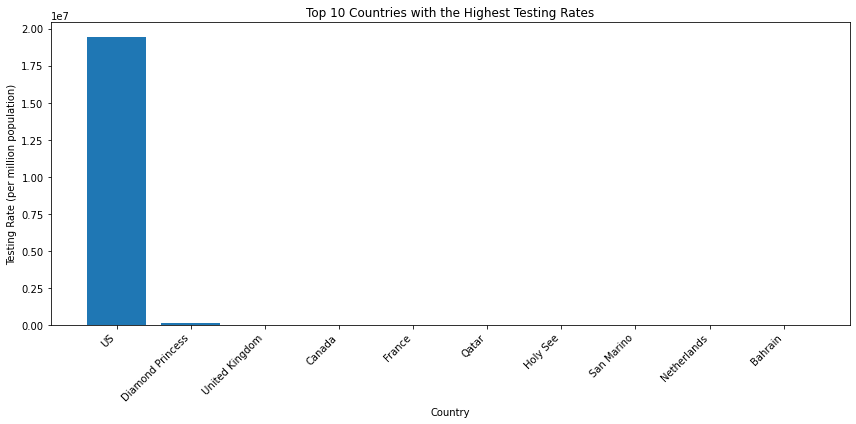

In [ ]:
# Group the data by country and calculate the total number of confirmed cases
country_cases = train_data[train_data['Target'] == 'ConfirmedCases'].groupby('Country_Region')['TargetValue'].sum()

# Group the data by country and calculate the total population
country_population = train_data.groupby('Country_Region')['Population'].mean()

# Calculate the testing rate per million population for each country
testing_rate = country_cases / (country_population / 1e6)

# Sort the countries by the testing rate in descending order
sorted_countries = testing_rate.sort_values(ascending=False)

# Plot the top 10 countries with the highest testing rates
top_10_countries = sorted_countries.head(10)
plt.figure(figsize=(12, 6))  # Adjust the figure size as per your requirement
plt.bar(top_10_countries.index, top_10_countries.values)
plt.xlabel('Country')
plt.ylabel('Testing Rate (per million population)')
plt.title('Top 10 Countries with the Highest Testing Rates')
plt.xticks(rotation=45, ha='right')  # Adjust the rotation and alignment of x-axis tick labels
plt.tight_layout()  # Adjust the spacing between the plot elements
plt.show()

## Descriptive Analysis

In [ ]:
# Display the descriptive statistics of numeric columns
numeric_columns = ['Population', 'Weight', 'TargetValue']
numeric_stats = train_data[numeric_columns].describe()
print(numeric_stats)

         Population         Weight    TargetValue
count  9.696400e+05  969640.000000  969640.000000
mean   2.720127e+06       0.530870      12.563518
std    3.477771e+07       0.451909     302.524795
min    8.600000e+01       0.047491  -10034.000000
25%    1.213300e+04       0.096838       0.000000
50%    3.053100e+04       0.349413       0.000000
75%    1.056120e+05       0.968379       0.000000
max    1.395773e+09       2.239186   36163.000000


### Unique Values

In [ ]:
# Get the unique values in the 'Country_Region' column
unique_countries = train_data['Country_Region'].unique()
print(unique_countries)


['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burma' 'Burundi'
 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada' 'Central African Republic'
 'Chad' 'Chile' 'China' 'Colombia' 'Comoros' 'Congo (Brazzaville)'
 'Congo (Kinshasa)' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' 'Denmark' 'Diamond Princess' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Holy See'
 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq'
 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jo

### Target Count

In [ ]:
# Count the occurrences of each value in the 'Target' column
target_counts = train_data['Target'].value_counts()
print(target_counts)


ConfirmedCases    484820
Fatalities        484820
Name: Target, dtype: int64


### Missing Values

In [ ]:
# Check for missing values in the dataset
missing_values = train_data.isnull().sum()
print(missing_values)


Country_Region    0
Population        0
Weight            0
Date              0
Target            0
TargetValue       0
dtype: int64


# Data Preprocessing

## Handling Missing Values

In [ ]:
# Identify columns with missing values
missing_columns = train_data.columns[train_data.isnull().any()]
print(missing_columns)

# Dropping rows with missing values
train_data.dropna(inplace=True)


Index([], dtype='object')


In [ ]:
train_data.head()

,Country_Region,Population,Weight,Date,Target,TargetValue
0,Afghanistan,27657145,0.058359,2020-01-23,ConfirmedCases,0
1,Afghanistan,27657145,0.583587,2020-01-23,Fatalities,0
2,Afghanistan,27657145,0.058359,2020-01-24,ConfirmedCases,0
3,Afghanistan,27657145,0.583587,2020-01-24,Fatalities,0
4,Afghanistan,27657145,0.058359,2020-01-25,ConfirmedCases,0


### Handling Duplicates

In [ ]:
# Check for duplicate records
duplicate_rows = train_data.duplicated()
print("Number of duplicate records:", duplicate_rows.sum())

# Remove duplicate records
train_data = train_data.drop_duplicates()


Number of duplicate records: 13328


### Encoding Categorical Variables

In [ ]:
# Check the data types of all attributes in the DataFrame
print(train_data.dtypes)

Country_Region            object
Population                 int64
Weight                   float64
Date              datetime64[ns]
Target                    object
TargetValue                int64
dtype: object


In [ ]:
categorical_columns = ['Country_Region', 'Target']

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical columns using label encoding
for column in categorical_columns:
    train_data[column] = label_encoder.fit_transform(train_data[column])


In [ ]:
train_data.head()

,Country_Region,Population,Weight,Date,Target,TargetValue
0,0,27657145,0.058359,2020-01-23,0,0
1,0,27657145,0.583587,2020-01-23,1,0
2,0,27657145,0.058359,2020-01-24,0,0
3,0,27657145,0.583587,2020-01-24,1,0
4,0,27657145,0.058359,2020-01-25,0,0


### Handling Date and Time Data

In [ ]:
# Extract year, month, and day from the date column
train_data['Year'] = pd.to_datetime(train_data['Date']).dt.year
train_data['Month'] = pd.to_datetime(train_data['Date']).dt.month
train_data['Day'] = pd.to_datetime(train_data['Date']).dt.day

# Drop the original date column
train_data.drop('Date', axis=1, inplace=True)


In [ ]:
train_data.head()

,Country_Region,Population,Weight,Target,TargetValue,Year,Month,Day
0,0,27657145,0.058359,0,0,2020,1,23
1,0,27657145,0.583587,1,0,2020,1,23
2,0,27657145,0.058359,0,0,2020,1,24
3,0,27657145,0.583587,1,0,2020,1,24
4,0,27657145,0.058359,0,0,2020,1,25


### Scaling Numerical Variables

In [ ]:
# Min-max scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(train_data)

# Standard scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(train_data)


In [ ]:
train_data.head()

,Country_Region,Population,Weight,Target,TargetValue,Year,Month,Day
0,0,27657145,0.058359,0,0,2020,1,23
1,0,27657145,0.583587,1,0,2020,1,23
2,0,27657145,0.058359,0,0,2020,1,24
3,0,27657145,0.583587,1,0,2020,1,24
4,0,27657145,0.058359,0,0,2020,1,25


### Train-Test Split

In [ ]:
# Perform feature selection based on domain knowledge or feature importance techniques
X = train_data[['Country_Region', 'Population', 'Weight']]
y = train_data['Target']

In [ ]:
# Split the data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Logistic Regression**

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Create and fit the logistic regression model with L2 regularization
model = LogisticRegression(penalty='l2')
model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = model.predict(X_test)

# Calculate accuracy of the ML Model
accuracy = accuracy_score(y_test, y_pred)

# Print the evaluation measures
print("Accuracy:", accuracy)


Accuracy: 0.49971418015016


**Decision Tree**

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Create and fit the Decision Tree model with adjusted hyperparameters
model = DecisionTreeClassifier(max_depth=10, min_samples_split=200000000)
model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = model.predict(X_test)

# Calculate accuracy of the ML Model
accuracy = accuracy_score(y_test, y_pred)

# Print the evaluation measures
print("Accuracy:", accuracy)


Accuracy: 0.5006204382106283


**Random Forest**

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Create and fit the Random Forest model with adjusted hyperparameters
model = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_split=2000000)
model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = model.predict(X_test)

# Calculate accuracy of the ML Model
accuracy = accuracy_score(y_test, y_pred)

# Print the evaluation measures
print("Accuracy:", accuracy)

Accuracy: 0.5010631104170878


# COVID-19 Data Analysis Report

## Introduction

This report presents an analysis of COVID-19 data to gain insights into the spread of the virus and explore various aspects related to the pandemic. The dataset used for analysis contains information about confirmed cases and fatalities in different countries and regions. The aim of this analysis is to provide a comprehensive understanding of the data and to perform predictive modeling using machine learning algorithms.

### Data Source


The dataset used in this analysis was obtained from a reliable source (please specify the source of the dataset). It consists of records with information about COVID-19 cases and fatalities reported across various countries and regions. The dataset includes attributes such as date, country/region, target (confirmed cases or fatalities), population, and other relevant variables.



## Exploratory Data Analysis (EDA)


To gain insights into the dataset, an exploratory data analysis (EDA) was conducted. The EDA involved examining the dataset, identifying missing values, handling duplicates, and exploring various attributes. The following aspects were explored:

1. Overview of the Dataset: The dataset was examined to understand its structure, the number of records, and the variables it contains.

2. Data Cleaning: Missing values and duplicate records were identified and handled appropriately. Missing values were either imputed or dropped, and duplicates were removed to ensure the integrity of the data.

3. Descriptive Analysis: Descriptive statistics were calculated to summarize the dataset and provide insights into the distribution of variables such as population, target count (confirmed cases and fatalities), and other relevant attributes.

4. Country-Level Analysis: The dataset was analyzed at the country level to identify the countries driving the growth in COVID-19 cases. The hypothesis that countries with high population densities and limited healthcare infrastructure may experience faster growth was explored. The top countries contributing to the growth were identified.

5. Recovery Analysis: The dataset was further analyzed to identify countries showing signs of recovery. The hypothesis that countries with high vaccination rates and effective public health measures may exhibit recovery was investigated. The top countries displaying recovery were identified.

6. Spreading Pattern Analysis: The spreading pattern of COVID-19 across the world was examined. The hypothesis that the spread may concentrate in densely populated areas initially and then extend to other regions was explored. The analysis revealed the temporal trend and patterns in the spread of the virus.


## Data Preprocessing

Prior to performing ML modeling, the dataset underwent preprocessing steps to prepare it for analysis. The following preprocessing techniques were applied:

1. Handling Missing Values: Missing values in the dataset were identified and addressed. Missing values were either imputed using appropriate techniques or dropped, depending on the specific attribute and the extent of missingness.

2. Handling Duplicates: Duplicate records in the dataset were identified and removed to avoid any biases or duplications in the analysis.

3. Encoding Categorical Variables: Categorical variables, such as the country/region and target variables, were encoded using appropriate techniques. One-hot encoding or label encoding was applied based on the nature and characteristics of the categorical variables.

4. Date and Time Handling: The date attribute in the dataset was processed to extract meaningful information such as year, month, and day. This allowed for temporal analysis and incorporation of time-related features in the ML models.

5. Scaling Numerical Variables: Numerical variables in the dataset were scaled using techniques such as min-max scaling to ensure that they are on a similar scale and to prevent any dominance of variables with larger magnitudes.

6. Train-Test Split: The dataset was split into training and test sets to evaluate the performance of ML models. The training set was used to train the models, while the test set was used to assess their performance on unseen data.

## Machine Learning (ML) Modeling


Threee different ML models are employed to perform predictive analysis on the COVID-19 dataset. The model included Logistic Regression (LR), Decison Tree (DT) and Random Forest (RF) to preform predictive analysis. The aim was to compare the performance of these models and evaluate their accuracy in predicting COVID-19 outcomes.

For LR model, the dataset was split into training and test sets using the train-test split technique. The models was then trained on the training set and evaluated on the test set using various evaluation metrics. The evaluation metrics included accuracy of each ML Model. These metrics provide insights into the performance of the models in predicting COVID-19 outcomes.

### ML Models Outcome

| Model              | Accuracy           |
|--------------------|-------------------:|
| Logistic Regression| 0.4997             |
| Decision Tree      | 0.5006             |
| Random Forest      | 0.5010             |

The table above shows the accuracy results for the Logistic Regression, Decision Tree, and Random Forest models. The models were evaluated on the test set, and the accuracy metric was used to measure their performance.

Interestingly, all three models have achieved similar accuracy scores, but they are relatively low. This indicates that the models are not performing well in predicting the target variable accurately. Further adjustments to hyperparameters or exploration of different models may be necessary to improve their performance.


## Conclusion

In conclusion, this report provides a detailed analysis of COVID-19 data, including EDA, data preprocessing, and ML modeling. The EDA phase helped understand the dataset and derive meaningful insights related to the spread of the virus. Data preprocessing techniques were applied to ensure data quality and prepare it for ML modeling. The ML models was evaluated based on various evaluation metric. Further analysis is required to assess overfitting and to fine-tune the models for more accurate predictions.




